In [6]:
%pip install mglearn

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense
np.random.seed(180)
tf.random.set_seed(180)
people=fetch_lfw_people(min_faces_per_person=20,resize=0.7)
print(people.data.shape)
print(people.target.shape)
image_shape=people.images[0].shape

(3023, 5655)
(3023,)


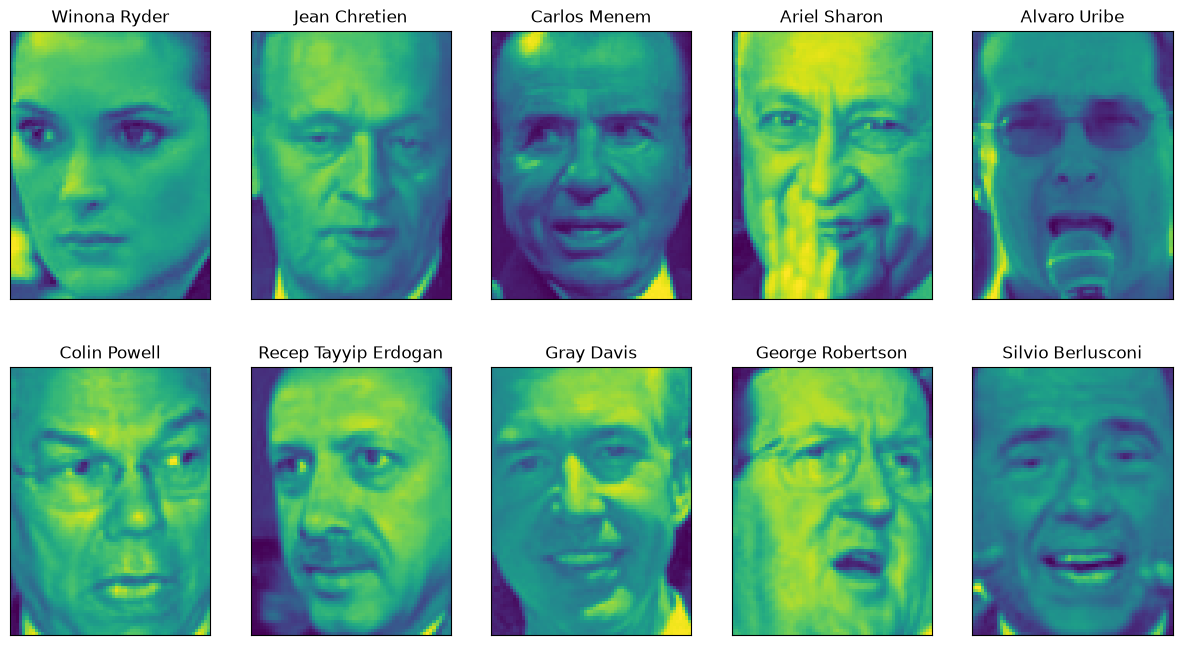

In [8]:
fix,axes=plt.subplots(2,5,figsize=(15,8),subplot_kw={'xticks':(),'yticks':()})
for target,image,ax in zip(people.target,people.images,axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target])
plt.show()
    

In [11]:
X_train,X_test,y_train,y_test=train_test_split(people.data,people.target,test_size=0.2,random_state=20)
y_train=y_train.astype(int)
y_test=y_test.astype(int)
batch_size=len(X_train)
print(X_train.shape,y_train.shape,y_test.shape)
print("people.images.shape:{}".format(people.images.shape))
print("Number of classes:{}".format(len(people.target_names)))


(2418, 5655) (2418,) (605,)
people.images.shape:(3023, 87, 65)
Number of classes:62


In [14]:
count=np.bincount(people.target)
for i,(count,name) in enumerate(zip(count,people.target_names)):
    print("{0:25} {1:3}".format(name,count),end="")
    if(i+1)%3==0:
        print()

Alejandro Toledo           39Alvaro Uribe               35Amelie Mauresmo            21
Andre Agassi               36Angelina Jolie             20Ariel Sharon               77
Arnold Schwarzenegger      42Atal Bihari Vajpayee       24Bill Clinton               29
Carlos Menem               21Colin Powell              236David Beckham              31
Donald Rumsfeld           121George Robertson           22George W Bush             530
Gerhard Schroeder         109Gloria Macapagal Arroyo    44Gray Davis                 26
Guillermo Coria            30Hamid Karzai               22Hans Blix                  39
Hugo Chavez                71Igor Ivanov                20Jack Straw                 28
Jacques Chirac             52Jean Chretien              55Jennifer Aniston           21
Jennifer Capriati          42Jennifer Lopez             21Jeremy Greenstock          24
Jiang Zemin                20John Ashcroft              53John Negroponte            31
Jose Maria Aznar           23Jua

In [18]:
mask=np.zeros(people.target.shape,dtype=np.bool_)
for target in np.unique(people.target):
    mask[np.where(people.target==target)[0][:50]]=True
X_people=people.data[mask]
y_people=people.target[mask]
X_people=X_people/255.0
X_train,X_test,y_train,y_test=train_test_split(X_people,y_people,stratify=y_people,random_state=0)
knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)
print("Test set score of 1-nn:{:.2f}".format(knn.score(X_test,y_test)))

Test set score of 1-nn:0.22


mglearn.plots.plot_pea_whitening()
plt.show()

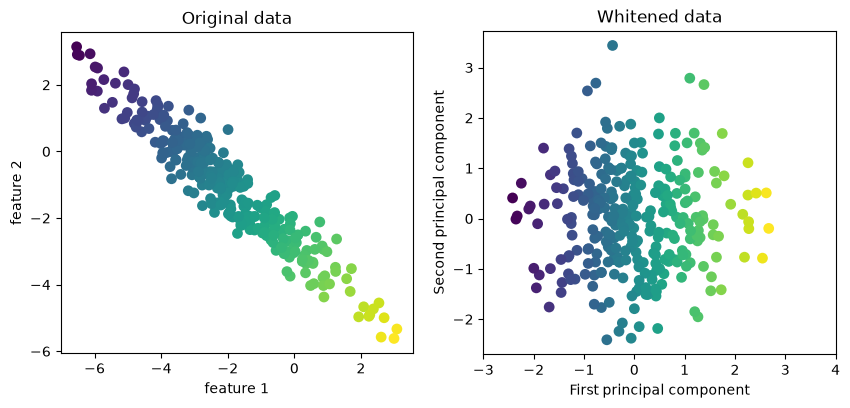

In [20]:
mglearn.plots.plot_pca_whitening()
plt.show()

In [24]:
pca=PCA(n_components=100,whiten=True,random_state=0).fit(X_train)
X_train_pca=pca.transform(X_train)
X_test_pca=pca.transform(X_test)
print("X_train_pca.shape:{}".format(X_train_pca.shape))
knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca,y_train)
print("Test set accuracy:{:.2f}".format(knn.score(X_test_pca,y_test)))
print("pca.components_.shape:{}".format(pca.components_.shape))


X_train_pca.shape:(1547, 100)
Test set accuracy:0.30
pca.components_.shape:(100, 5655)


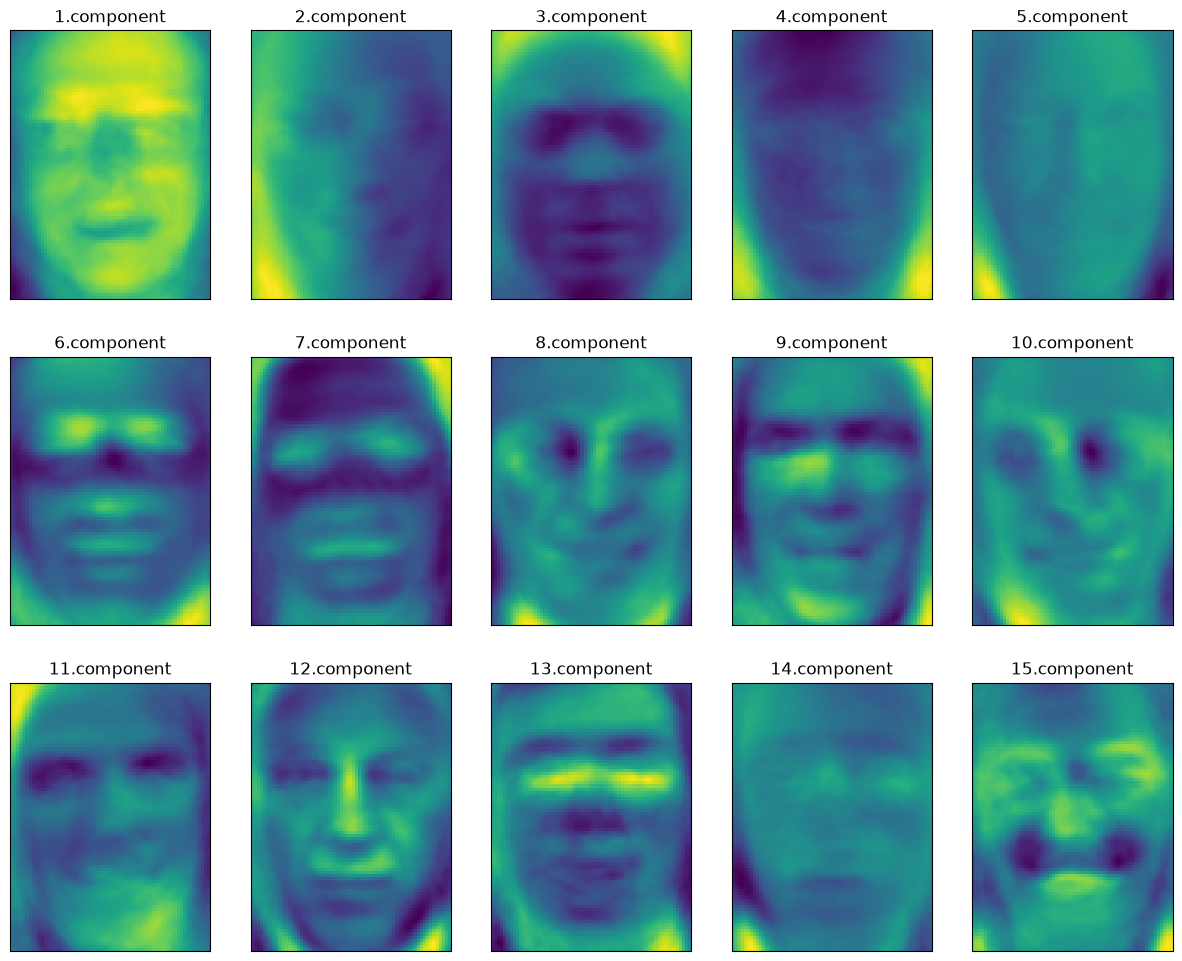

In [28]:
fix,axes=plt.subplots(3,5,figsize=(15,12),subplot_kw={'xticks':(),'yticks':()})
for i,(component,ax) in enumerate(zip(pca.components_,axes.ravel())):
    ax.imshow(component.reshape(image_shape),cmap='viridis')
    ax.set_title("{}.component".format(i+1))
plt.show()

In [37]:
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train_pca)
X_test_scaled=scaler.transform(X_test_pca)
model=Sequential([Input(shape=(100,)),Dense(300,activation='relu'),Dense(100,activation='relu'),Dense(len(np.unique(y_train)),activation='softmax')])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False,verbose=1)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0200 - loss: 4.1245   
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0252 - loss: 4.0856 
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0343 - loss: 4.0568 
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0511 - loss: 4.0318 
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0653 - loss: 4.0009 
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0814 - loss: 3.9657 
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0976 - loss: 3.9243 
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1267 - loss: 3.8701 
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1454 - loss: 3.8053 
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1745 - loss: 3.7232 
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1978 - loss: 3.6222 
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy

In [38]:
loss,accuracy=model.evaluate(X_test_scaled,y_test,verbose=1)
print("Test Loss:",loss)
print("Test Accuracy:",accuracy)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3217 - loss: 2.8645 
Test Loss: 2.8644697666168213
Test Accuracy: 0.3217054307460785
